In [59]:
import h5py
import numpy as np
import trimesh
import pyrender
import pandas as pd
from PIL import Image

In [45]:
frame_id = 0

## Extract camera extrinsics (camera to world)

In [47]:
with h5py.File("../hyperism/ai_001_001/_detail/cam_00/camera_keyframe_orientations.hdf5", "r") as f:
    camera_orientations = np.array(f["dataset"])

with h5py.File("../hyperism/ai_001_001/_detail/cam_00/camera_keyframe_positions.hdf5", "r") as f:
    camera_positions = np.array(f["dataset"])

In [82]:
camera_position_world = camera_positions[frame_id]
R_world_from_cam      = camera_orientations[frame_id]

c2w = np.eye(4)
c2w[:3, :3] = R_world_from_cam
c2w[:3, 3] = camera_position_world


In [83]:
c2w

array([[ 7.41193831e-01, -3.51180434e-01,  5.72105408e-01,
         1.03228874e+02],
       [ 5.79402149e-01, -9.57124457e-02, -8.09399724e-01,
        -1.17227142e+02],
       [ 3.39002311e-01,  9.31402802e-01,  1.32532686e-01,
         6.23017311e+01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

## Extract bbox mesh

In [28]:
with h5py.File("../hyperism/ai_001_001/_detail/mesh/metadata_semantic_instance_bounding_box_object_aligned_2d_extents.hdf5") as f:
    extents = np.array(f["dataset"])

with h5py.File("../hyperism/ai_001_001/_detail/mesh/metadata_semantic_instance_bounding_box_object_aligned_2d_orientations.hdf5") as f:
    orientations = np.array(f["dataset"])

with h5py.File("../hyperism/ai_001_001/_detail/mesh/metadata_semantic_instance_bounding_box_object_aligned_2d_positions.hdf5") as f:
    positions = np.array(f["dataset"])

## Extract camera intrinsics

In [84]:
# from https://github.com/apple/ml-hypersim/blob/main/contrib/mikeroberts3000/jupyter/02_rendering_hypersim_meshes_with_pytorch3d.ipynb
camera_metadata = pd.read_csv("../hyperism/metadata_camera_parameters.csv", index_col="scene_name")
df_ = camera_metadata.loc["ai_001_001"]

width_pixels  = int(df_["settings_output_img_width"])
height_pixels = int(df_["settings_output_img_height"])

if df_["use_camera_physical"]:
    fov_x = df_["camera_physical_fov"]
else:
    fov_x = df_["settings_camera_fov"]

fov_y = 2.0 * np.arctan(height_pixels * np.tan(fov_x/2.0) / width_pixels)
aspect_ratio = width_pixels / height_pixels

In [86]:
fov_y, width_pixels, height_pixels, aspect_ratio

(np.float64(0.8172757347349127), 1024, 768, 1.3333333333333333)

## Render Scene

In [78]:
boxes = []
for i in range(extents.shape[0]):
    transform = np.eye(4)
    transform[:3, :3] = orientations[i]
    transform[:3,  3] = positions[i]

    box = trimesh.creation.box(extents=np.array(extents[i]), transform=transform)
    boxes.append(box)

tm_scene = trimesh.util.concatenate(boxes)

In [87]:
pr_mesh = pyrender.Mesh.from_trimesh(tm_scene)
pr_scene = pyrender.Scene()
pr_scene.add(pr_mesh)

camera = pyrender.PerspectiveCamera(yfov=fov_y, aspectRatio=width_pixels/height_pixels)
pr_scene.add(camera, pose=c2w)

light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=3.0)
pr_scene.add(light, pose=c2w)

r = pyrender.OffscreenRenderer(width_pixels, height_pixels)
color, depth = r.render(pr_scene)

img = Image.fromarray(color)
img.save("../outputs/rendered_hyperism.png")

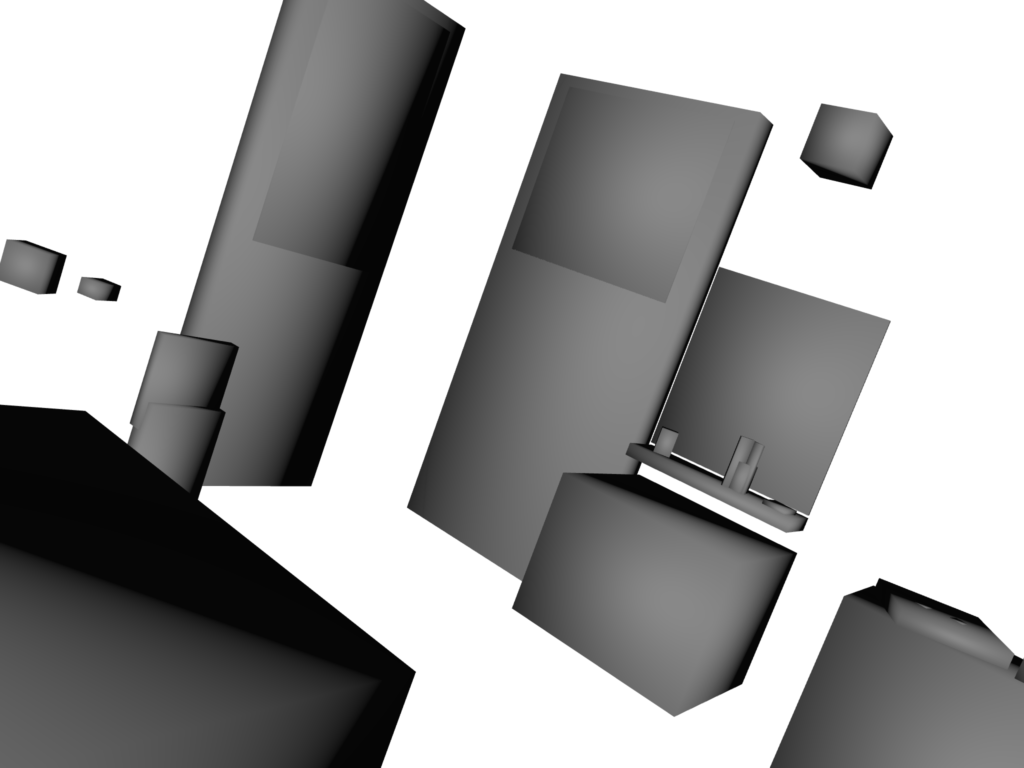

In [80]:
img